In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import random
%config InlineBackend.figure_formats = ['svg']

# Running RB

Just to make sure I understand RB experiments.

For standard RB: we characterizer average error per Clifford gate of the 216 elements of the single-qutrit Clifford group $\mathcal{C}_3$. Steps

1. Prepare $|0\rangle$
2. Generate a sequence of $L-1$ gates. Each gate is randomly sampled from $\mathcal{C}_3$.
3. Classically compute an inverse gate and add to the end of the sequence. This makes the entire sequence (comprising of $L-1+1$ gates) implements an ideally identity operator. We call this sequence a seed of length $L$.
4. Measure the survival propability of $|0\rangle$, $|1\rangle$, and $|2\rangle$. Calculate $\langle Z\rangle=P_0+\omega P_1+\omega^2 P_2$. Take the real part, denote $\langle Z_\text{real}\rangle$.
5. Repeat steps 1 - 4 again with a different seed (of the same length $L$) $N$ times for statistics.
6. Increasing $L$ from 1 to 800. For each $L$, repeat 1 - 5.

Each point of the $y$-array in `EZ_uc.csv` and `EZ_c.csv` is the *mean* value of $\langle Z_\text{real}\rangle$ over $N$ times at each length $L$.

# Load data

In [105]:
fname = "./pops/pop_pi12_c.csv"
loadedArr = np.loadtxt(fname)
max_depth = 800
depth_arr = np.arange(0, max_depth + 25, 25)/2

pop_arrays = loadedArr.reshape(loadedArr.shape[0], loadedArr.shape[1] // 33, 33)

In [106]:
pop_arrays.shape

(40, 3, 33)

In [107]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

# Track visited indices
visited_indices = set()

# UI Elements
idx = widgets.IntText(value=0, description='Index:')
next_button = widgets.Button(description="Next")
back_button = widgets.Button(description="Back")
save_button = widgets.Button(description="Save Plot")
status_output = widgets.Output()
plot_output = widgets.Output()

# Plotting function
def plot(idx_val):
    with plot_output:
        clear_output(wait=True)
        plt.figure(figsize=(6, 4))
        plt.scatter(depth_arr, pop_arrays[idx_val, 0, :])  # Adjust axis if needed
        plt.plot(depth_arr, np.mean(pop_arrays[:, 0, :], axis=0), color='red')
        plt.ylim(0, 1)
        plt.axhline(0.33333, color='tab:blue', linestyle='--')
        plt.title(f"Index: {idx_val}")
        plt.show()
    visited_indices.add(idx_val)
    check_if_done()

# Save function
def save_plot(_):
    idx_val = idx.value
    filename = f'./figures/H_uc/pop_arrays_{idx_val}.png'
    plt.figure(figsize=(6, 3))
    plt.scatter(depth_arr, pop_arrays[idx_val, 0, :])
    plt.plot(depth_arr, np.mean(pop_arrays[:, 0, :], axis=0), color='red')
    plt.ylim(0, 1)
    plt.axhline(0.33333, color='r', linestyle='--')
    plt.title(f"Index: {idx_val}")
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    with status_output:
        print(f"Saved: {filename}")

# Button: Next
def on_next_clicked(_):
    if idx.value + 1 < pop_arrays.shape[0]:
        idx.value += 1
    else:
        with status_output:
            print("Already at last index.")

# Button: Back
def on_back_clicked(_):
    if idx.value - 1 >= 0:
        idx.value -= 1
    else:
        with status_output:
            print("Already at first index.")

# Index change handler
def on_idx_changed(change):
    if 0 <= change['new'] < pop_arrays.shape[0]:
        plot(change['new'])

# Check if all i's have been visited
def check_if_done():
    with status_output:
        clear_output(wait=False)
        total = pop_arrays.shape[0]
        visited = len(visited_indices)
        if visited == total:
            print("✅ All indices have been visited.")
        else:
            print(f"Visited {visited} of {total} indices.")

# Event bindings
next_button.on_click(on_next_clicked)
back_button.on_click(on_back_clicked)
save_button.on_click(save_plot)
idx.observe(on_idx_changed, names='value')

# Display UI and initial plot
display(widgets.HBox([back_button, idx, next_button, save_button]))
display(plot_output)
display(status_output)
plot(idx.value)

Output()

Output()

### Post-select

In [108]:
# post_select_indices = [13, 14, 15, 18, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 32, 33, 34, 36, 37, 38] # uc 
# post_select_indices = [0, 1, 13, 14, 15, 16, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32] # uc previous
# post_select_indices = [1, 2, 3, 10, 11, 12, 24, 25, 26, 33, 16, 19, 21, 22, 23, 29, 30, 31, 32, 20] # c
# post_select_indices = [7, 8, 12, 16, 20, 23, 25, 26, 27, 1, 3, 4, 5, 15, 17, 24, 28, 29, 30, 32] # pi12 uc previous
# post_select_indices = [15, 18, 29, 30, 31, 32, 34, 35, 37, 0, 1, 2, 3, 4, 5, 6, 7, 20, 25, 26] # pi12 uc
post_select_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 17, 26, 37, 27, 23] # pi12 c
# post_select_indices = [0, 2, 6, 8, 12, 14, 16, 19, 20, 26, 27, 28, 29, 30, 31, 32, 33, 34, 38, 25] # H uc
# post_select_indices = [2, 3, 4, 5, 9, 10, 11, 12, 13, 14, 15, 20, 21, 23, 24, 26, 31, 33, 32, 25] # H c previous
# post_select_indices = [2, 28, 35, 9, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 25, 27, 29, 32, 33, 34] # H c
# post_select_indices = np.arange(0, pop_arrays.shape[0], 1) # full

if len(post_select_indices) > len(set(post_select_indices)):
    print('Not unique')
print(len(post_select_indices))

filtered_pop_arrays = pop_arrays[post_select_indices]

20


In [109]:
def decay_func(m, A, f, B):
    return A * f**m + B

initial_guess = [1, 0.9, 0]

params_0, cov_0 = curve_fit(decay_func, depth_arr, np.mean(filtered_pop_arrays[:, 0, :], axis=0), p0=initial_guess)

A_fit, f_fit, B_fit = params_0
print(f"Fitted parameters:\nA = {A_fit}\nf = {f_fit}\nB = {B_fit}")
print(cov_0)

Fitted parameters:
A = 0.5758886010788581
f = 0.9967259419302018
B = 0.4338762854861626
[[ 1.18525735e-03  1.28562948e-05 -1.30676524e-03]
 [ 1.28562948e-05  1.57606280e-07 -1.50833214e-05]
 [-1.30676524e-03 -1.50833214e-05  1.49256359e-03]]


In [110]:
def decay_func_12(m, A, f, B):
    return 1/3 - A * f**m + B

initial_guess = [1, 0.9, 0]

params_0, cov_0 = curve_fit(decay_func, depth_arr, np.mean(filtered_pop_arrays[:, 0, :], axis=0), p0=initial_guess)
params_1, cov_1 = curve_fit(decay_func_12, depth_arr, np.mean(filtered_pop_arrays[:, 1, :], axis=0), p0=initial_guess)
params_2, cov_2 = curve_fit(decay_func_12, depth_arr, np.mean(filtered_pop_arrays[:, 2, :], axis=0), p0=initial_guess)

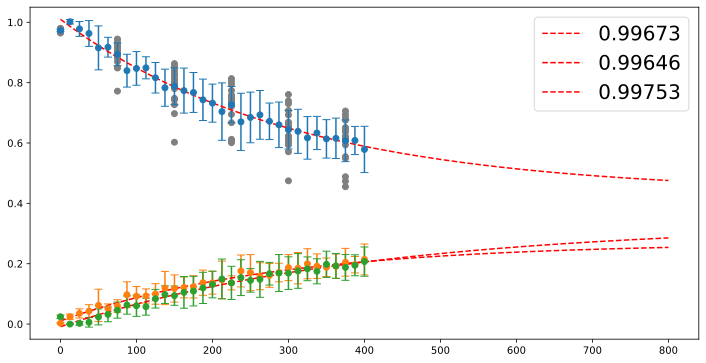

In [111]:
fig, ax = plt.subplots(figsize=(12, 6))

for i in range(len(post_select_indices)):
    ax.scatter(depth_arr[::6], filtered_pop_arrays[i, 0, :][::6], color='gray')

ax.errorbar(depth_arr, np.mean(filtered_pop_arrays[:, 0, :], axis=0), yerr=np.std(filtered_pop_arrays[:, 0, :], axis=0), fmt='o', capsize=4)
ax.errorbar(depth_arr, np.mean(filtered_pop_arrays[:, 1, :], axis=0), yerr=np.std(filtered_pop_arrays[:, 1, :], axis=0), fmt='o', capsize=4)
ax.errorbar(depth_arr, np.mean(filtered_pop_arrays[:, 2, :], axis=0), yerr=np.std(filtered_pop_arrays[:, 2, :], axis=0), fmt='o', capsize=4)
ax.set_ylim([-0.05, 1.05])

m_fit = np.linspace(0, max_depth, 500)
fit_vals_0 = decay_func(m_fit, *params_0)
fit_vals_1 = decay_func_12(m_fit, *params_1)
fit_vals_2 = decay_func_12(m_fit, *params_2)

ax.plot(m_fit, fit_vals_0, 'r--', label=f'{np.round(params_0[1],5)}')
ax.plot(m_fit, fit_vals_1, 'r--', label=f'{np.round(params_1[1],5)}')
ax.plot(m_fit, fit_vals_2, 'r--', label=f'{np.round(params_2[1],5)}')
ax.legend(fontsize=20)

In [112]:
def expectZ(p0, p1, p2):
    return p0 + np.exp(2*np.pi*1j/3) * p1 + np.exp(4*np.pi*1j/3) * p2

In [113]:
p0 = np.mean(filtered_pop_arrays[:, 0, :], axis=0)
p1 = np.mean(filtered_pop_arrays[:, 1, :], axis=0)
p2 = np.mean(filtered_pop_arrays[:, 2, :], axis=0)

In [114]:
my_expectZ = expectZ(p0, p1, p2)

from scipy.optimize import minimize

def decay_func(m, A, f, B):
    return A * f**m + B

def loss(params, m, y):
    A, f, B = params
    return np.sum((decay_func(m, A, f, B) - y)**2)

initial_guess = [1, 0.9, 0]

bounds = [(0, 1), (0, 1), (-1, 1)]

# Constraint: A + B <= 1
constraints = [{'type': 'ineq', 'fun': lambda x: 1 - (x[0] + x[2])}]

result = minimize(
    loss,
    initial_guess,
    args=(depth_arr, np.real(my_expectZ)),
    bounds=bounds,
    constraints=constraints,
)

# Extract fitted parameters
A_fit, f_fit, B_fit = result.x
print(f"Fitted parameters:\nA = {A_fit}\nf = {f_fit}\nB = {B_fit}")
print("Optimization success:", result.success)
print("Message:", result.message)

# Generate fitted values
fit_vals = decay_func(m_fit, A_fit, f_fit, B_fit)

# Double-check constraint
print("Max fitted value:", np.max(fit_vals))

# Optional: visualize or check that all fit values < 1
assert np.all(fit_vals <= 1 + 1e-8), "Warning: some fitted values exceed 1!"

Fitted parameters:
A = 0.8891539082394082
f = 0.9970264297371888
B = 0.1108460917605917
Optimization success: True
Message: Optimization terminated successfully
Max fitted value: 0.9999999999999999


You can estimate the standard deviation (uncertainty) of f_fit from the covariance matrix of the fitted parameters. scipy.optimize.minimize does not provide this directly, but you can approximate it from the Hessian (second derivative matrix) at the optimum.

In [115]:
from numpy.linalg import inv

eps = np.sqrt(np.finfo(float).eps)
n = len(result.x)
hessian = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        x_ij1 = result.x.copy()
        x_ij2 = result.x.copy()
        x_ij3 = result.x.copy()
        x_ij4 = result.x.copy()
        x_ij1[i] += eps; x_ij1[j] += eps
        x_ij2[i] += eps; x_ij2[j] -= eps
        x_ij3[i] -= eps; x_ij3[j] += eps
        x_ij4[i] -= eps; x_ij4[j] -= eps
        hessian[i, j] = (loss(x_ij1, depth_arr, np.real(my_expectZ))
                         - loss(x_ij2, depth_arr, np.real(my_expectZ))
                         - loss(x_ij3, depth_arr, np.real(my_expectZ))
                         + loss(x_ij4, depth_arr, np.real(my_expectZ))) / (4 * eps**2)

# Covariance matrix approximation (inverse of Hessian)
cov = inv(hessian)
# If your loss is a true least-squares (sum of squared residuals), you can scale the covariance by the residual variance:
residuals = np.real(my_expectZ) - decay_func(depth_arr, A_fit, f_fit, B_fit)
sigma2 = np.sum(residuals**2) / (len(depth_arr) - len(result.x))
cov *= sigma2

# Standard deviations of parameters
param_std = np.sqrt(np.diag(cov))
std = param_std[1]

print(f"Standard deviation of f_fit ≈ {param_std[1]}")

Standard deviation of f_fit ≈ 0.0002676671948310677


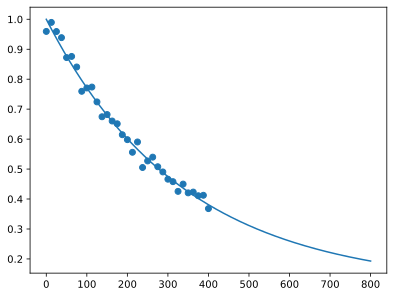

In [116]:
plt.scatter(depth_arr, np.real(my_expectZ))
plt.plot(m_fit, fit_vals)

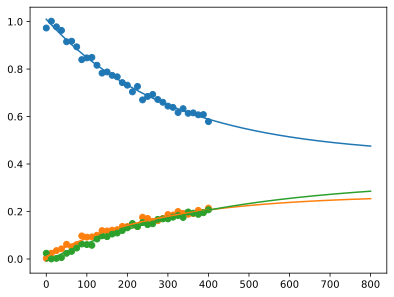

In [117]:
plt.scatter(depth_arr, p0)
plt.plot(m_fit, fit_vals_0)
plt.scatter(depth_arr, p1)
plt.plot(m_fit, fit_vals_1)
plt.scatter(depth_arr, p2)
plt.plot(m_fit, fit_vals_2)

In [118]:
np.savez('./rb_pi12_c.npz', depth_arr=depth_arr, m_fit=m_fit, p0=p0, p1=p1, p2=p2, expectZ=np.real(my_expectZ), fit_vals_0=fit_vals_0, fit_vals_1=fit_vals_1, fit_vals_2=fit_vals_2, fit_vals=fit_vals, f_fit=f_fit, std=std)

In [152]:
index_depth = 26

for p in filtered_pop_arrays[:, 0, index_depth]:
    print(f'{p},')

0.5382617770590853,
0.5116255608087029,
0.4422356796576784,
0.477949792816254,
0.45694975936466053,
0.32467203354308816,
0.3868505637932112,
0.4837368716940445,
0.3728802723752912,
0.37983027688935006,
0.3608148386061428,
0.26703094643258907,
0.4249796911588264,
0.4494749536078014,
0.37846567367064116,
0.3066792458667231,
0.3874904081184736,
0.3849074484758473,
0.4169873038397148,
0.32368871551515627,
